# Audio Window Features: Quick Robustness Check and EDA

This notebook performs a quick exploratory analysis and robustness check on `audio_window_features.tsv`.

Checks included:
- schema and missingness
- key uniqueness and temporal consistency
- distribution summaries and outlier flags
- task/group-level stability snapshots
- feature correlation overview

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [3]:
data_path = Path("../results/audio_window_features.tsv")
if not data_path.exists():
    raise FileNotFoundError(f"Could not find: {data_path.resolve()}")

df = pd.read_csv(data_path, sep="\t")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
df.head(3)

Rows: 526 | Columns: 70


,group_id,task_id,window_index,window_start_s,audio_energy_mean,audio_pitch_mean,audio_pitch_sd,audio_hnr_mean,gemap_F0semitoneFrom27.5Hz_sma3nz_amean,gemap_F0semitoneFrom27.5Hz_sma3nz_stddevNorm,gemap_F0semitoneFrom27.5Hz_sma3nz_percentile20.0,gemap_F0semitoneFrom27.5Hz_sma3nz_percentile50.0,gemap_F0semitoneFrom27.5Hz_sma3nz_percentile80.0,gemap_F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,gemap_F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,gemap_F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,gemap_F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,gemap_F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,gemap_loudness_sma3_amean,gemap_loudness_sma3_stddevNorm,gemap_loudness_sma3_percentile20.0,gemap_loudness_sma3_percentile50.0,gemap_loudness_sma3_percentile80.0,gemap_loudness_sma3_pctlrange0-2,gemap_loudness_sma3_meanRisingSlope,gemap_loudness_sma3_stddevRisingSlope,gemap_loudness_sma3_meanFallingSlope,gemap_loudness_sma3_stddevFallingSlope,gemap_jitterLocal_sma3nz_amean,gemap_jitterLocal_sma3nz_stddevNorm,gemap_shimmerLocaldB_sma3nz_amean,gemap_shimmerLocaldB_sma3nz_stddevNorm,gemap_HNRdBACF_sma3nz_amean,gemap_HNRdBACF_sma3nz_stddevNorm,gemap_logRelF0-H1-H2_sma3nz_amean,gemap_logRelF0-H1-H2_sma3nz_stddevNorm,gemap_logRelF0-H1-A3_sma3nz_amean,gemap_logRelF0-H1-A3_sma3nz_stddevNorm,gemap_F1frequency_sma3nz_amean,gemap_F1frequency_sma3nz_stddevNorm,gemap_F1bandwidth_sma3nz_amean,gemap_F1bandwidth_sma3nz_stddevNorm,gemap_F1amplitudeLogRelF0_sma3nz_amean,gemap_F1amplitudeLogRelF0_sma3nz_stddevNorm,gemap_F2frequency_sma3nz_amean,gemap_F2frequency_sma3nz_stddevNorm,gemap_F2amplitudeLogRelF0_sma3nz_amean,gemap_F2amplitudeLogRelF0_sma3nz_stddevNorm,gemap_F3frequency_sma3nz_amean,gemap_F3frequency_sma3nz_stddevNorm,gemap_F3amplitudeLogRelF0_sma3nz_amean,gemap_F3amplitudeLogRelF0_sma3nz_stddevNorm,gemap_alphaRatioV_sma3nz_amean,gemap_alphaRatioV_sma3nz_stddevNorm,gemap_hammarbergIndexV_sma3nz_amean,gemap_hammarbergIndexV_sma3nz_stddevNorm,gemap_slopeV0-500_sma3nz_amean,gemap_slopeV0-500_sma3nz_stddevNorm,gemap_slopeV500-1500_sma3nz_amean,gemap_slopeV500-1500_sma3nz_stddevNorm,gemap_alphaRatioUV_sma3nz_amean,gemap_hammarbergIndexUV_sma3nz_amean,gemap_slopeUV0-500_sma3nz_amean,gemap_slopeUV500-1500_sma3nz_amean,gemap_loudnessPeaksPerSec,gemap_VoicedSegmentsPerSec,gemap_MeanVoicedSegmentLengthSec,gemap_StddevVoicedSegmentLengthSec,gemap_MeanUnvoicedSegmentLength,gemap_StddevUnvoicedSegmentLength
0,grp-07,T1,0,0.0,0.109416,23.936003,0.207996,1.817083,23.936003,0.207996,20.347174,24.050120,27.836688,7.489514,255.554260,268.872074,122.056494,129.014748,0.109416,0.833129,0.043041,0.073030,0.160217,0.117176,1.689589,1.128586,1.291846,0.882043,0.050678,1.883545,1.445380,0.659402,1.817083,119.046877,2.461132,28.395949,20.814924,0.818541,482.763268,0.426791,1158.548920,0.204572,-144.264751,-0.595896,1527.181580,0.167837,-147.354801,-0.541238,2557.085754,0.104345,-148.788490,-0.520921,-16.453870,-0.410508,25.541075,0.274681,0.008094,7.038937,-0.010376,-1.112086,-20.171325,30.782852,-0.061692,0.001370,1.775592,1.862058,0.154204,0.117829,0.388843,0.762345
1,grp-07,T1,1,30.0,0.110551,23.453197,0.188979,1.165167,23.453197,0.188979,21.340343,23.456221,25.632736,4.292393,228.075447,234.405981,136.362560,165.632652,0.110551,0.684268,0.041530,0.092349,0.165283,0.123753,1.325354,0.756564,1.005105,0.546460,0.060706,1.914218,1.494080,0.600717,1.165167,3.929338,4.268894,3.450618,21.916543,0.499110,446.553772,0.391525,1149.562775,0.205187,-131.236963,-0.682036,1451.741394,0.156233,-135.136990,-0.616768,2537.975037,0.085825,-137.255869,-0.586650,-16.251905,-0.366355,24.837601,0.297226,0.001119,-4.260908,-0.010779,-1.023405,-20.438233,30.931194,-0.057142,-0.000566,2.859286,2.273293,0.147344,0.140436,0.254697,0.369505
2,grp-07,T1,2,60.0,0.065333,23.598001,0.195372,0.965169,23.598001,0.195372,19.966530,23.513668,27.542894,7.576364,216.568077,150.584250,56.203251,66.860314,0.065333,0.729956,0.037056,0.043611,0.086262,0.049206,1.190530,0.866840,0.854926,0.578892,0.054281,1.293150,

In [3]:
id_cols = ["group_id", "task_id", "window_index", "window_start_s"]
missing_summary = df.isna().mean().sort_values(ascending=False).rename("missing_rate")

print("Top missingness rates:")
display(missing_summary.head(15).to_frame())

dupe_count = df.duplicated(subset=id_cols).sum()
print(f"Duplicate rows on key {id_cols}: {dupe_count}")

window_check = (
    df.sort_values(["group_id", "task_id", "window_index"])
      .groupby(["group_id", "task_id"])["window_start_s"]
      .diff()
)
expected_step = 30.0
bad_steps = ((window_check.notna()) & (~np.isclose(window_check, expected_step))).sum()
print(f"Non-{expected_step:.0f}s window step transitions: {bad_steps}")

counts = df.groupby(["group_id", "task_id"], as_index=False).size()
counts.rename(columns={"size": "n_windows"}, inplace=True)
display(counts.pivot(index="group_id", columns="task_id", values="n_windows").fillna(0).astype(int))

Top missingness rates:


,missing_rate
group_id,0.0
task_id,0.0
window_index,0.0
window_start_s,0.0
audio_energy_mean,0.0
audio_pitch_mean,0.0
audio_pitch_sd,0.0
audio_hnr_mean,0.0
gemap_F0semitoneFrom27.5Hz_sma3nz_amean,0.0
gemap_F0semitoneFrom27.5Hz_sma3nz_stddevNorm,0.0


Duplicate rows on key ['group_id', 'task_id', 'window_index', 'window_start_s']: 0
Non-30s window step transitions: 15


task_id,T1,T2,T3
group_id,,,
grp-07,9,27,13
grp-08,25,34,25
grp-09,0,20,21
grp-10,13,25,13
grp-11,16,26,17
grp-12,19,28,0
grp-13,18,23,0
grp-14,15,23,13
grp-15,15,22,13


In [4]:

sorted_df = df.sort_values(["group_id", "task_id", "window_index"]).copy()
sorted_df["_step"] = sorted_df.groupby(["group_id", "task_id"])["window_start_s"].diff()

bad_mask = sorted_df["_step"].notna() & ~np.isclose(sorted_df["_step"], 30.0)
bad_rows = sorted_df[bad_mask][["group_id", "task_id", "window_index", "window_start_s", "_step"]].copy()
bad_rows.rename(columns={"_step": "step_from_prev_s"}, inplace=True)

# Classify: gap (missed window) or overlap (duplicate/repeat)
bad_rows["type"] = np.where(bad_rows["step_from_prev_s"] > 30.0, "gap", "overlap/repeat")
display(bad_rows.reset_index(drop=True))


,group_id,task_id,window_index,window_start_s,step_from_prev_s,type
0,grp-08,T1,5,150.0,60.0,gap
1,grp-08,T1,23,690.0,120.0,gap
2,grp-08,T3,5,150.0,60.0,gap
3,grp-08,T3,11,330.0,150.0,gap
4,grp-08,T3,31,930.0,90.0,gap
5,grp-09,T3,6,180.0,150.0,gap
6,grp-11,T1,15,450.0,90.0,gap
7,grp-11,T2,5,150.0,90.0,gap
8,grp-11,T2,26,780.0,60.0,gap
9,grp-12,T1,6,180.0,90.0,gap


In [4]:
core_cols = [
    "audio_energy_mean",
    "audio_pitch_mean",
    "audio_pitch_sd",
    "audio_hnr_mean",
    "gemap_loudness_sma3_amean",
    "gemap_jitterLocal_sma3nz_amean",
    "gemap_shimmerLocaldB_sma3nz_amean",
    "gemap_HNRdBACF_sma3nz_amean",
]

summary = df[core_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
display(summary)

def robust_outlier_fraction(series: pd.Series, thresh: float = 3.5) -> float:
    x = series.dropna().to_numpy(dtype=float)
    if x.size < 5:
        return np.nan
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        return 0.0
    z = 0.6745 * (x - med) / mad
    return float(np.mean(np.abs(z) > thresh))

outlier_rates = pd.Series({c: robust_outlier_fraction(df[c]) for c in core_cols}, name="robust_outlier_fraction")
display(outlier_rates.sort_values(ascending=False).to_frame())

,count,mean,std,min,1%,5%,50%,95%,99%,max
audio_energy_mean,526.0,0.181785,0.102955,0.039766,0.041215,0.045782,0.168403,0.362148,0.528927,0.679462
audio_pitch_mean,526.0,26.346908,5.557548,9.987659,10.380061,13.512318,26.227620,34.633193,35.558883,36.638218
audio_pitch_sd,526.0,0.212812,0.066993,0.022618,0.049138,0.090600,0.211538,0.328028,0.403762,0.503091
audio_hnr_mean,526.0,3.524968,2.509077,-4.865747,-3.386889,-1.458137,3.636465,7.115844,7.905221,9.601838
gemap_loudness_sma3_amean,526.0,0.181785,0.102955,0.039766,0.041215,0.045782,0.168403,0.362148,0.528927,0.679462
gemap_jitterLocal_sma3nz_amean,526.0,0.043282,0.014911,0.000000,0.011624,0.024311,0.041885,0.066180,0.082775,0.185053
gemap_shimmerLocaldB_sma3nz_amean,526.0,1.347773,0.284647,0.845036,1.003471,1.065748,1.284718,1.940423,2.547064,3.131523
gemap_HNRdBACF_sma3nz_amean,526.0,3.524968,2.509077,-4.865747,-3.386889,-1.458137,3.636465,7.115844,7.905221,9.601838


,robust_outlier_fraction
gemap_shimmerLocaldB_sma3nz_amean,0.055133
audio_energy_mean,0.017110
gemap_loudness_sma3_amean,0.017110
audio_pitch_sd,0.013308
gemap_jitterLocal_sma3nz_amean,0.009506
audio_hnr_mean,0.003802
gemap_HNRdBACF_sma3nz_amean,0.003802
audio_pitch_mean,0.000000


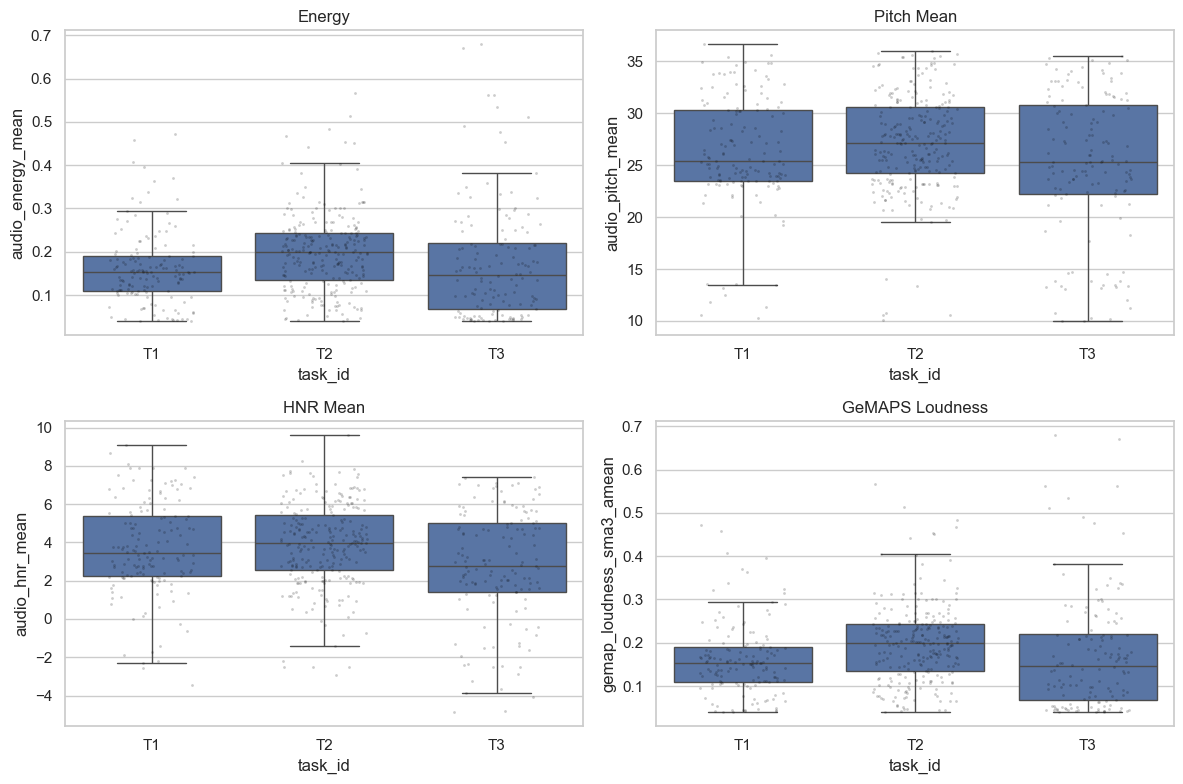

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_specs = [
    ("audio_energy_mean", "Energy"),
    ("audio_pitch_mean", "Pitch Mean"),
    ("audio_hnr_mean", "HNR Mean"),
    ("gemap_loudness_sma3_amean", "GeMAPS Loudness"),
]

for ax, (col, title) in zip(axes.flat, plot_specs):
    sns.boxplot(data=df, x="task_id", y=col, ax=ax, showfliers=False)
    sns.stripplot(data=df.sample(min(len(df), 1000), random_state=42), x="task_id", y=col, ax=ax,
                  color="black", alpha=0.2, size=2, jitter=0.25)
    ax.set_title(title)

plt.tight_layout()
plt.show()

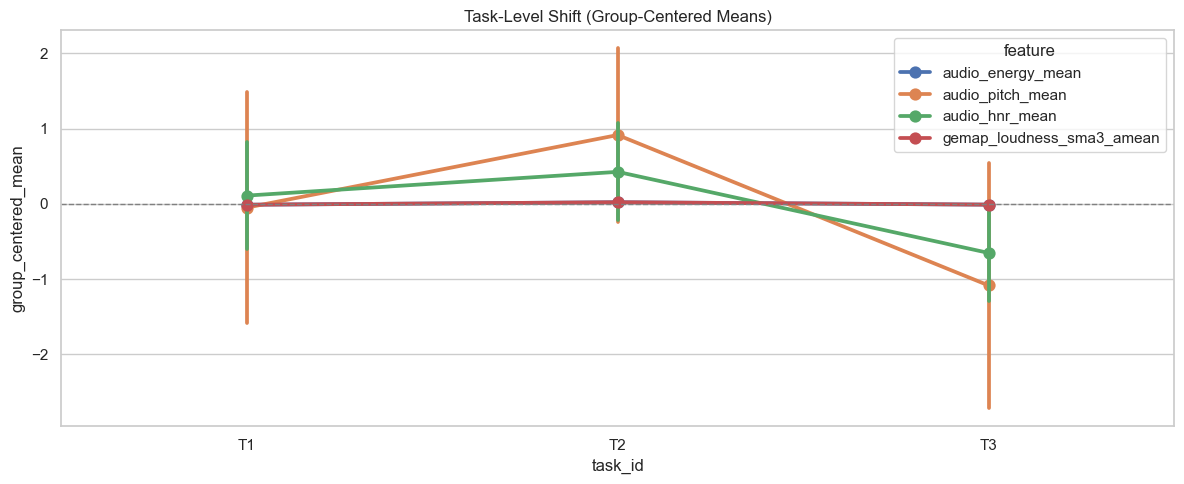

In [6]:
group_task = df.groupby(["group_id", "task_id"], as_index=False)[core_cols].mean()

# Group-centered task signal helps separate task effect from between-group baseline differences.
group_centered = group_task.copy()
for c in core_cols:
    group_centered[c] = group_centered[c] - group_centered.groupby("group_id")[c].transform("mean")

long_gc = group_centered.melt(
    id_vars=["group_id", "task_id"],
    value_vars=["audio_energy_mean", "audio_pitch_mean", "audio_hnr_mean", "gemap_loudness_sma3_amean"],
    var_name="feature",
    value_name="group_centered_mean",
)

plt.figure(figsize=(12, 5))
sns.pointplot(data=long_gc, x="task_id", y="group_centered_mean", hue="feature", errorbar="sd")
plt.axhline(0.0, color="gray", linewidth=1, linestyle="--")
plt.title("Task-Level Shift (Group-Centered Means)")
plt.tight_layout()
plt.show()

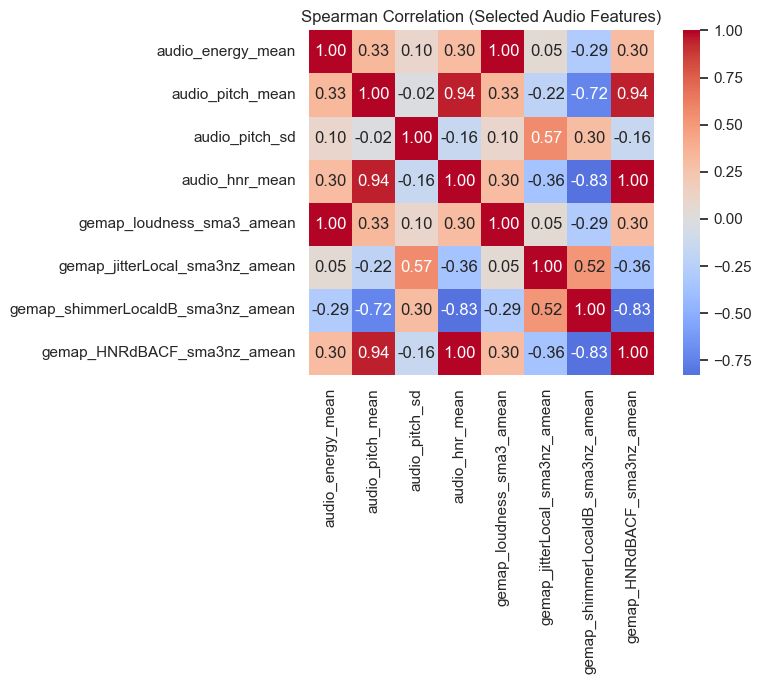

,audio_energy_mean,audio_pitch_mean,audio_pitch_sd,audio_hnr_mean,gemap_loudness_sma3_amean,gemap_jitterLocal_sma3nz_amean,gemap_shimmerLocaldB_sma3nz_amean,gemap_HNRdBACF_sma3nz_amean
audio_energy_mean,1.000000,0.332249,0.098288,0.302659,1.000000,0.045703,-0.294977,0.302659
audio_pitch_mean,0.332249,1.000000,-0.017806,0.943728,0.332249,-0.220181,-0.720010,0.943728
audio_pitch_sd,0.098288,-0.017806,1.000000,-0.155997,0.098288,0.568198,0.300343,-0.155997
audio_hnr_mean,0.302659,0.943728,-0.155997,1.000000,0.302659,-0.359754,-0.826966,1.000000
gemap_loudness_sma3_amean,1.000000,0.332249,0.098288,0.302659,1.000000,0.045703,-0.294977,0.302659
gemap_jitterLocal_sma3nz_amean,0.045703,-0.220181,0.568198,-0.359754,0.045703,1.000000,0.518982,-0.359754
gemap_shimmerLocaldB_sma3nz_amean,-0.294977,-0.720010,0.300343,-0.826966,-0.294977,0.518982,1.000000,-0.826966
gemap_HNRdBACF_sma3nz_amean,0.302659,0.943728,-0.155997,1.000000,0.302659,-0.359754,-0.826966,1.000000


In [7]:
corr_features = [
    "audio_energy_mean",
    "audio_pitch_mean",
    "audio_pitch_sd",
    "audio_hnr_mean",
    "gemap_loudness_sma3_amean",
    "gemap_jitterLocal_sma3nz_amean",
    "gemap_shimmerLocaldB_sma3nz_amean",
    "gemap_HNRdBACF_sma3nz_amean",
]
corr = df[corr_features].corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True)
plt.title("Spearman Correlation (Selected Audio Features)")
plt.tight_layout()
plt.show()

corr

In [8]:
print("Quick interpretation checklist:")
print("1. Missingness should be low for core features and keys.")
print("2. Duplicate key rows and non-30s window jumps should be near zero.")
print("3. Outlier rates should be modest for robust stability.")
print("4. Task-level group-centered shifts should show coherent directional patterns.")
print("5. Correlations should align with expected acoustic relationships.")

Quick interpretation checklist:
1. Missingness should be low for core features and keys.
2. Duplicate key rows and non-30s window jumps should be near zero.
3. Outlier rates should be modest for robust stability.
4. Task-level group-centered shifts should show coherent directional patterns.
5. Correlations should align with expected acoustic relationships.
